In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset.csv")

# Aperçu
print(df.head())
print(df.info())
print(df.describe())

# Valeurs manquantes
print(df.isnull().sum())

# Doublons
print(df.duplicated().sum())
df = df.drop_duplicates()

   Unnamed: 0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0           0            6      148             72             35        0   
1           1            1       85             66             29        0   
2           2            8      183             64              0        0   
3           3            1       89             66             23       94   
4           4            0      137             40             35      168   

    BMI  DiabetesPedigreeFunction  Age  
0  33.6                     0.627   50  
1  26.6                     0.351   31  
2  23.3                     0.672   32  
3  28.1                     0.167   21  
4  43.1                     2.288   33  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies           

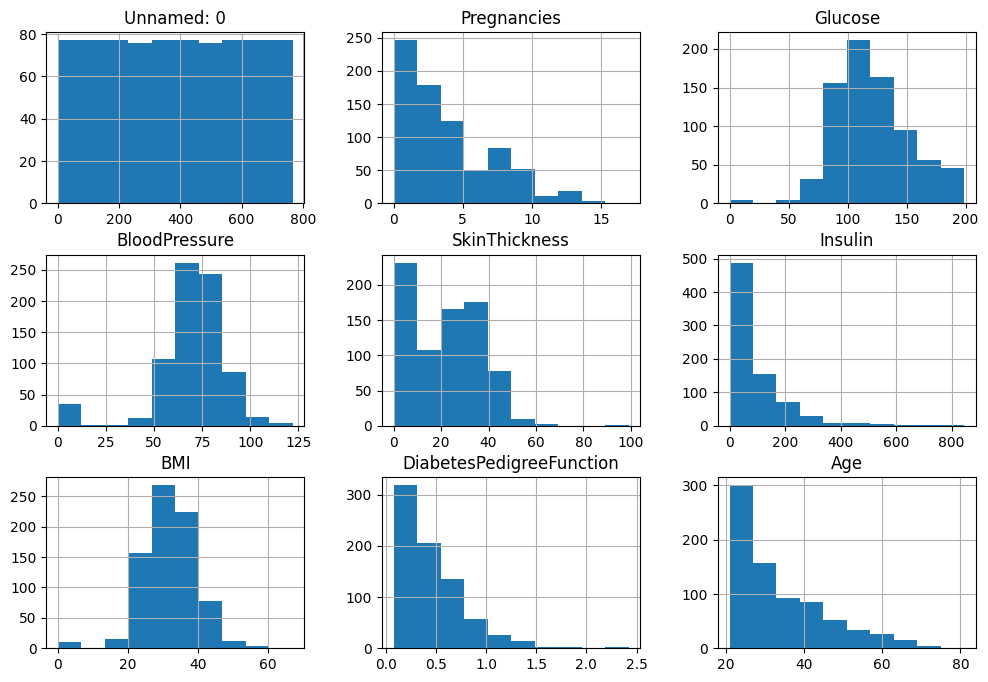

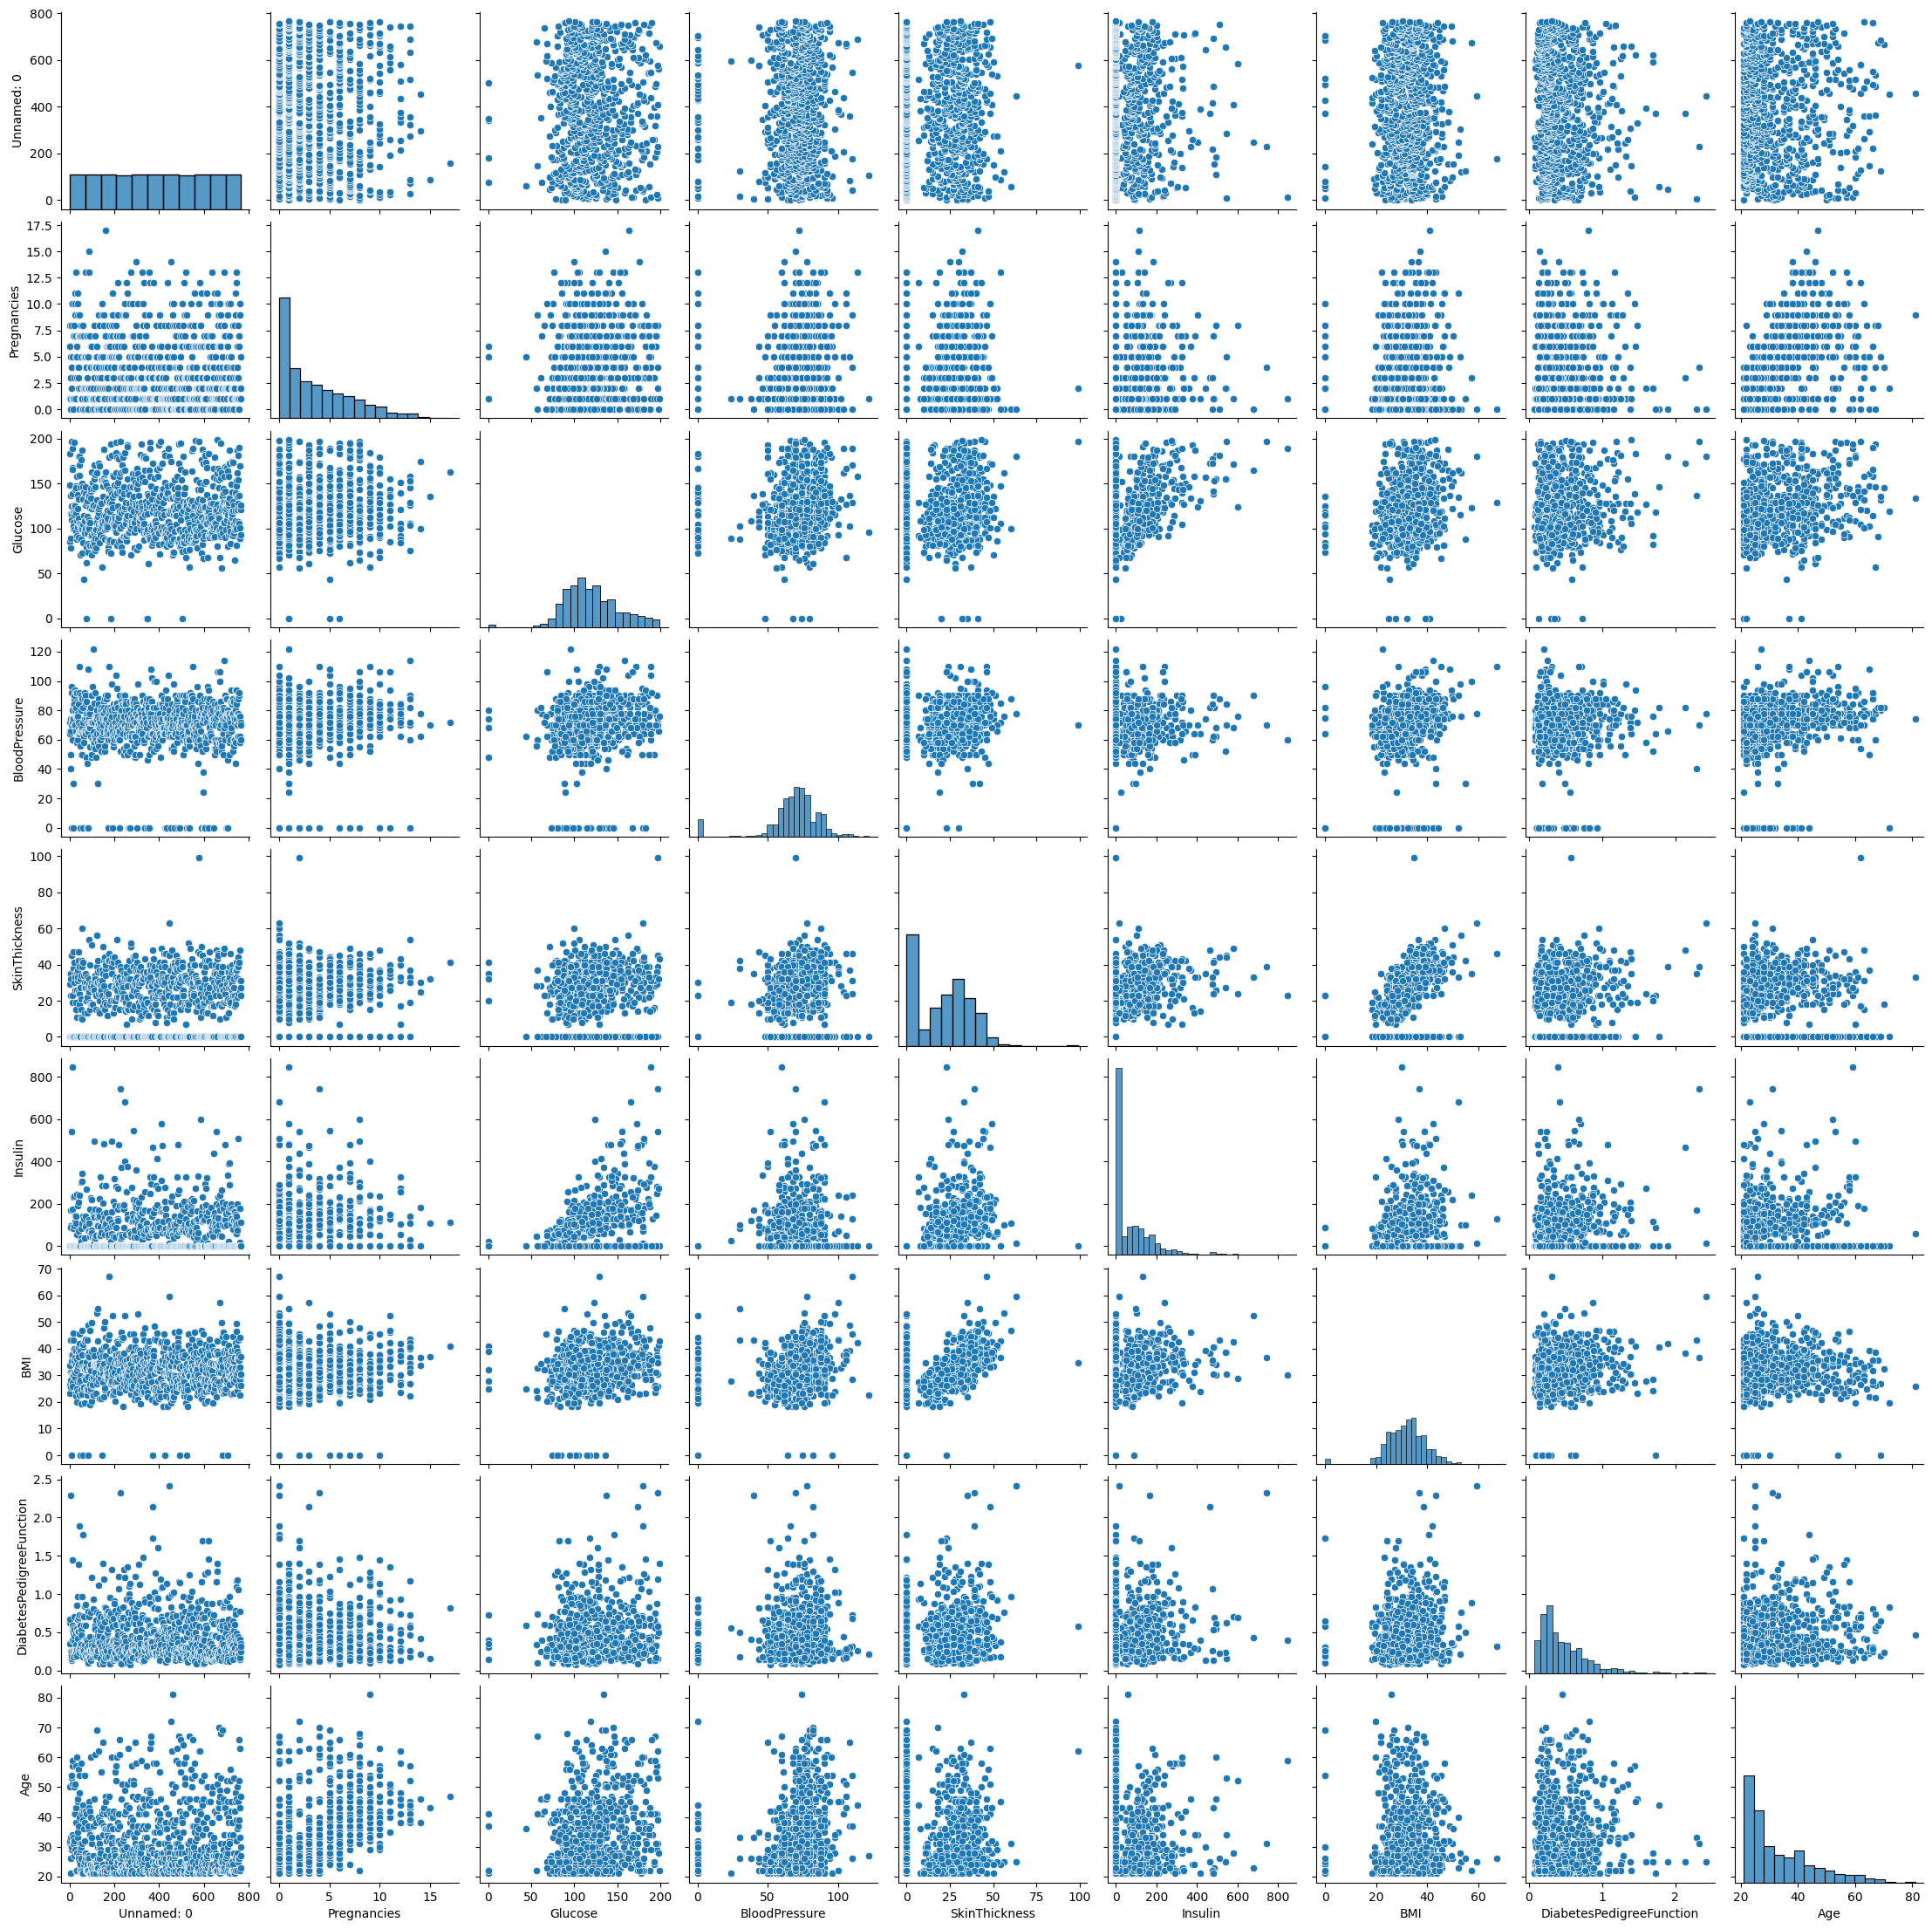

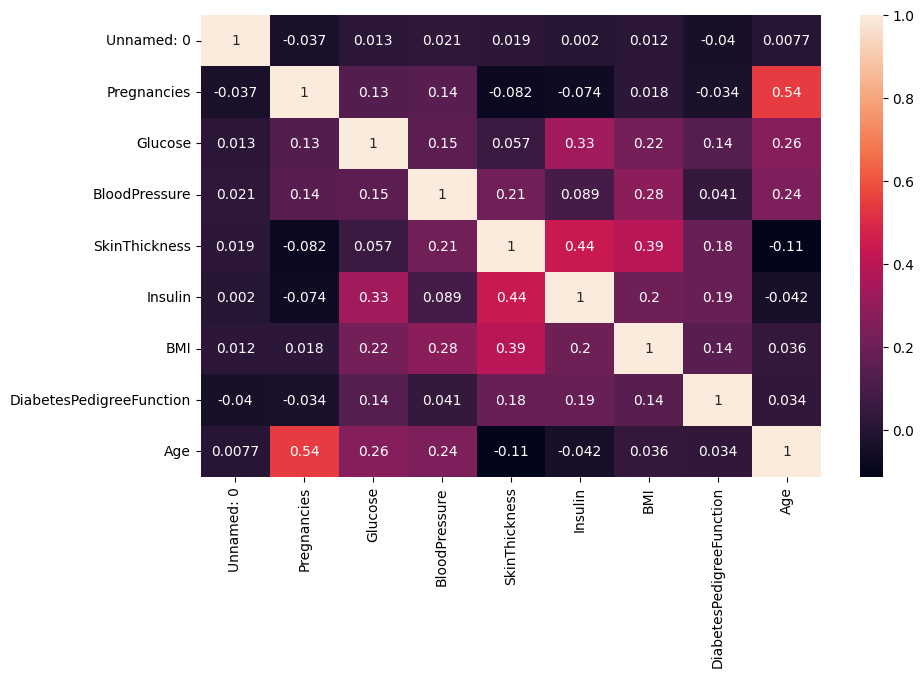

In [2]:
df.hist(figsize=(12,8))
plt.show()

sns.pairplot(df)
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [3]:
df.fillna(df.median(), inplace=True)

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...,...
763,763,10,101,76,48,180,32.9,0.171,63
764,764,2,122,70,27,0,36.8,0.340,27
765,765,5,121,72,23,112,26.2,0.245,30
766,766,1,126,60,0,0,30.1,0.349,47


In [4]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []

K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

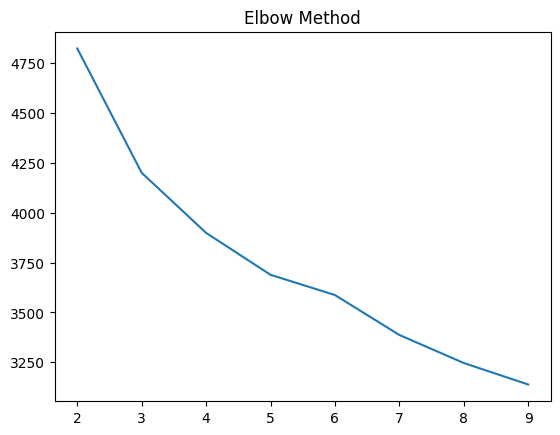

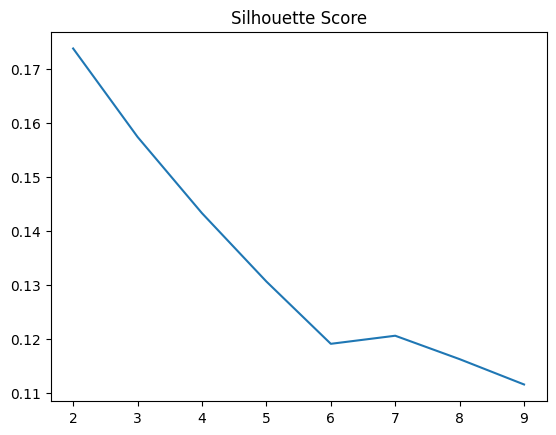

In [7]:
plt.plot(K_range, inertia)
plt.title("Elbow Method")
plt.show()

plt.plot(K_range, silhouette)
plt.title("Silhouette Score")
plt.show()

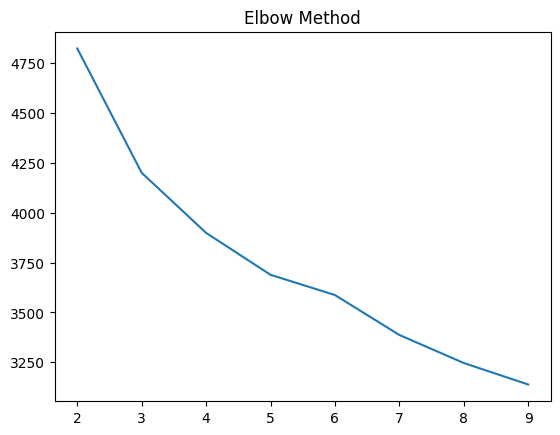

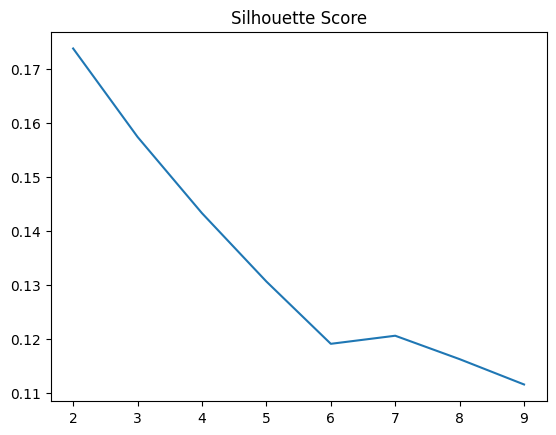

In [8]:
plt.plot(K_range, inertia)
plt.title("Elbow Method")
plt.show()

plt.plot(K_range, silhouette)
plt.title("Silhouette Score")
plt.show()

In [9]:
k = 3  # exemple
kmeans = KMeans(n_clusters=k, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [10]:
print(df.groupby("Cluster").mean())
print(df["Cluster"].value_counts())

         Unnamed: 0  Pregnancies     Glucose  BloodPressure  SkinThickness  \
Cluster                                                                      
0        384.175182     2.102190  102.930657      66.408759      18.806569   
1        374.741758     6.681319  128.016484      77.890110       9.532967   
2        407.754098     3.491803  134.486339      74.934426      34.163934   

            Insulin        BMI  DiabetesPedigreeFunction        Age  
Cluster                                                              
0         45.558394  29.020073                  0.386690  25.321168  
1         10.780220  31.956044                  0.386291  43.521978  
2        151.284153  36.525683                  0.535443  33.038251  
Cluster
0    274
2    183
1    182
Name: count, dtype: int64


In [11]:
risk_cluster = df.groupby("Cluster")[["Glucose","BMI","DiabetesPedigreeFunction"]].mean()

print(risk_cluster)

            Glucose        BMI  DiabetesPedigreeFunction
Cluster                                                 
0        102.930657  29.020073                  0.386690
1        128.016484  31.956044                  0.386291
2        134.486339  36.525683                  0.535443


In [12]:
X = df.drop("Cluster", axis=1)
y = df["Cluster"]

In [14]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ros = RandomOverSampler()
X_train, y_train = ros.fit_resample(X_train, y_train)

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [16]:
models = {
    "RF": RandomForestClassifier(),
    "SVM": SVC(),
    "GB": GradientBoostingClassifier(),
    "LR": LogisticRegression(),
    "DT": DecisionTreeClassifier(),
    "XGB": XGBClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, model.score(X_test, y_test))

RF 0.8984375
SVM 0.78125
GB 0.90625
LR 0.7421875
DT 0.8515625


C:\Users\LATIFA\Desktop\AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGB 0.90625


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[58  1  2]
 [ 0 31  2]
 [ 3  4 27]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        61
           1       0.86      0.94      0.90        33
           2       0.87      0.79      0.83        34

    accuracy                           0.91       128
   macro avg       0.89      0.89      0.89       128
weighted avg       0.91      0.91      0.91       128



In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


In [19]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [20]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl", "rb"))

st.title("Diabetes Risk Predictor")

glucose = st.number_input("Glucose")
bmi = st.number_input("BMI")
dpf = st.number_input("DPF")

if st.button("Predict"):
    data = np.array([[glucose, bmi, dpf]])
    pred = model.predict(data)
    
    st.write("Cluster:", pred[0])

ModuleNotFoundError: No module named 'streamlit'